In [2]:
import tensorflow as tf
from tensorflow import keras

/Users/apple/Desktop/mission D/deep_learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
data=keras.datasets.cifar10.load_data()


In [6]:
(X_train ,y_train),(X_test,y_test) = data

In [7]:
X_test.shape

(10000, 32, 32, 3)

In [8]:
X_train.shape

(50000, 32, 32, 3)

In [9]:
X_train[0:5]

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [10]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

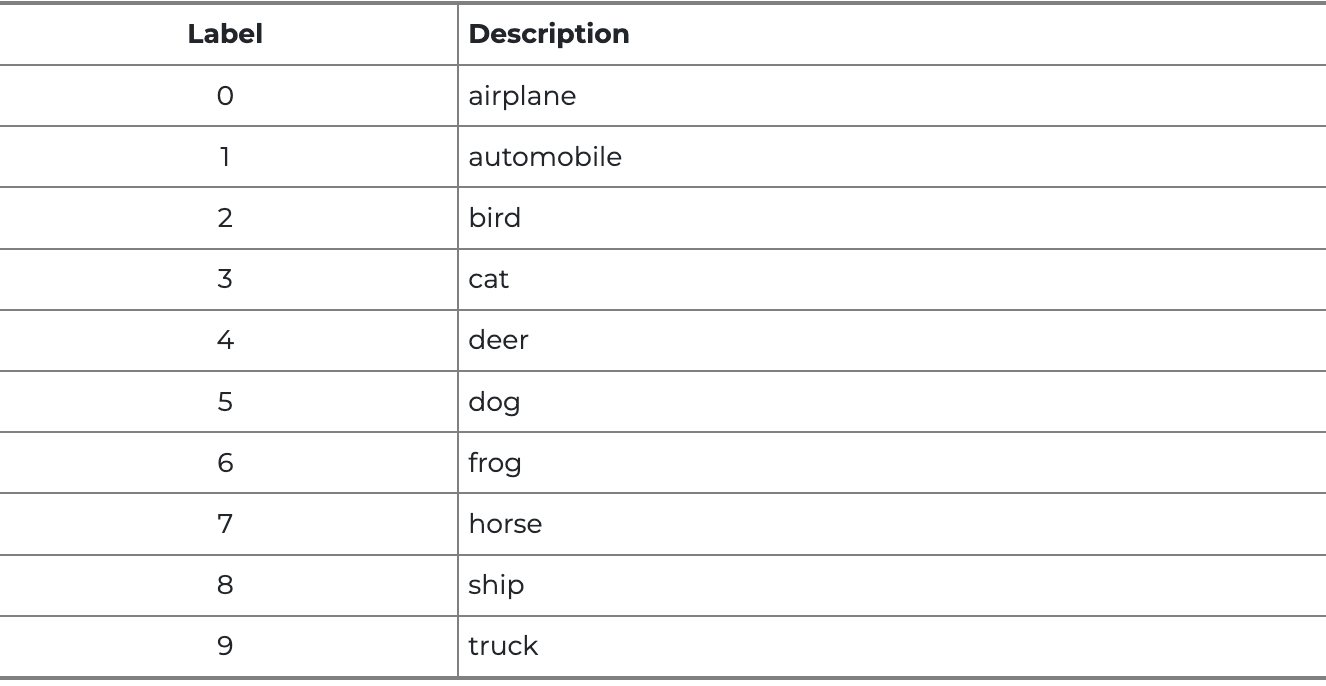

In [11]:


def plot_sample(index):
    plt.figure(figsize=(10,2))
    plt.imshow(X_train[index])
    plt.show()

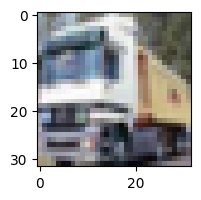

In [12]:
plot_sample(1)

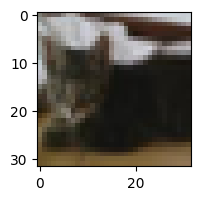

In [13]:
plot_sample(9)

In [14]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

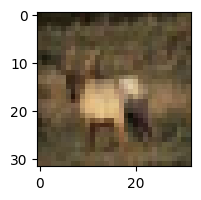

In [15]:
plot_sample(3)

In [16]:
classes[y_train[3][0]]

'deer'

In [17]:
classes[y_train[8][0]]

'ship'

sacling the data 

In [18]:
x_train_scaled = X_train / 255.0
x_test_scaled = X_test / 255.0

In [19]:
x_train_scaled

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [20]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [21]:
y_train_categorical = keras.utils.to_categorical(

    y_train,num_classes=10
)

In [22]:
y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

here we have one hot encoding that see there is a 1 in place of the 6 and the others are give as the 0 

In [23]:
y_test_categorical = keras.utils.to_categorical(

    y_test,num_classes=10
)

In [24]:
y_test_categorical[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

now model building 

In [25]:
X_train.shape

(50000, 32, 32, 3)

so we have to flatten it yeah so that we can iterate through it

In [26]:
32*32*3

3072

In [27]:
model =keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(32,32,3)),
        keras.layers.Dense(128 , activation='relu'),
        keras.layers.Dense(64 , activation='relu'),
        keras.layers.Dense(10,activation='sigmoid')
    ]
)


## bhaiya yaha pe jo layers kde bagal me numbers likhe hue hai vo koi random numbers nahi hai vo hai
# vo hai sare neuron that is they will give that much numbers as output

model.compile(optimizer='adam',
             loss='categorical_crossentropy',
              metrics=['accuracy']

             )

#aur jaba aapka data one hot encode ho to use karo categoricacal_crossentropy
# yaha pe sgd works better in categorical value and same for the 

/Users/apple/Desktop/mission D/deep_learning/venv/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-04-10 17:45:54.458398: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-10 17:45:54.458465: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-10 17:45:54.458909: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-10 17:45:54.458938: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-10 17:45:54.458949: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow dev

In [32]:
model.fit(x_train_scaled,y_train_categorical,epochs=20)

Epoch 1/20


2026-04-10 17:13:06.520224: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.2095 - loss: 2.4736
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.2839 - loss: 2.1250
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.2786 - loss: 2.1497
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.2005 - loss: 2.3905
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.1574 - loss: 3.0310
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.1434 - loss: 3.4946
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.1300 - loss: 4.2660
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.1228 - loss: 5.0569
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.1201 - loss: 5.9850
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.1156 - loss: 7.5332
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.1119 - loss: 8.4765
Epoch 12/20
1563/15

In [37]:
np.argmax(model.predict(x_test_scaled)[2])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0

In [35]:
classes[y_test[0][0]]

'cat'

In [40]:
model2 = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [41]:
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
model1.fit(x_train_scaled,y_train_categorical,epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.3732 - loss: 1.7209
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5501 - loss: 1.2907
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.5566 - loss: 1.3286
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5266 - loss: 1.7408
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.4775 - loss: 3.0961
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.4385 - loss: 6.6521
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.4114 - loss: 14.0400
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.3800 - loss: 27.0399
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.3688 - loss: 45.3142
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.3528 - loss: 75.0675
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.3434 - loss: 107.2792
Ep

In [43]:
model =keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(32,32,3)),
        keras.layers.Dense(2000 , activation='relu'),
        keras.layers.Dense(400 , activation='relu'),
        keras.layers.Dense(10,activation='sigmoid')
    ]
)


## bhaiya yaha pe jo layers kde bagal me numbers likhe hue hai vo koi random numbers nahi hai vo hai
# vo hai sare neuron that is they will give that much numbers as output

model.compile(optimizer='adam',
             loss='categorical_crossentropy',
              metrics=['accuracy']

             )

#aur jaba aapka data one hot encode ho to use karo categoricacal_crossentropy
# yaha pe sgd works better in categorical value and same for the 

/Users/apple/Desktop/mission D/deep_learning/venv/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model2 = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(2500, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(400, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/Users/apple/Desktop/mission D/deep_learning/venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model2.fit(x_train_scaled,y_train_categorical,epochs=30)

Epoch 1/30


2026-04-10 17:46:59.666969: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 207s 131ms/step - accuracy: 0.4209 - loss: 1.6239
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 130ms/step - accuracy: 0.6079 - loss: 1.1423
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.6044 - loss: 1.3244
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 130ms/step - accuracy: 0.5740 - loss: 2.2334
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 130ms/step - accuracy: 0.5374 - loss: 4.8575
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 210s 134ms/step - accuracy: 0.5242 - loss: 10.3662
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 228s 146ms/step - accuracy: 0.5299 - loss: 17.1286
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 209s 134ms/step - accuracy: 0.5211 - loss: 29.2372
Epoch 9/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.5284 - loss: 44.8842
Epoch 10/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 246s 157ms/step - accuracy: 0.5237 - loss: 68.0878
Epoch 11/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 253s 162ms/step - accuracy: 0.5142 - loss: